#### **Atividade de nivelamento - LACEDA**
**Integrante:** Laís Abib

##### Importação das bibliotecas usadas e definição das bases

In [101]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##

base_departamentos = 'dados/departamentos.csv'
base_filiais = 'dados/filiais.csv'
base_funcionarios = 'dados/funcionarios.csv'
base_resultado = 'dados/base_final.csv'

df_departamentos = pd.read_csv(base_departamentos)
df_filiais = pd.read_csv(base_filiais)
df_funcionarios = pd.read_csv(base_funcionarios)

##### Tratamento da base de funcionários

In [102]:

df_funcionarios["nome"] = df_funcionarios["nome"].str.replace(r"[0-9]", "", regex=True)

df_funcionarios["genero"] = df_funcionarios["genero"].replace({"Fem": "Feminino"})

df_funcionarios["data_admissao"] = np.where(
df_funcionarios["data_admissao"].str.contains("/", na=False), 
pd.to_datetime(df_funcionarios["data_admissao"], format="%d/%m/%Y", errors="coerce"),
pd.to_datetime(df_funcionarios["data_admissao"], format="%Y-%m-%d", errors="coerce")
)

df_funcionarios["data_promocao"] = np.where(
df_funcionarios["data_promocao"].str.contains("/", na=False), 
pd.to_datetime(df_funcionarios["data_promocao"], format="%d/%m/%Y", errors="coerce"),
pd.to_datetime(df_funcionarios["data_promocao"], format="%Y-%m-%d", errors="coerce")
)

df_funcionarios["salario_base"] = df_funcionarios["salario_base"].str.replace("R$", "", regex=False).str.strip()
df_funcionarios["salario_base"] = df_funcionarios["salario_base"].str.replace(".", ",", regex=False).str.strip()
df_funcionarios["salario_base"] = df_funcionarios["salario_base"].str.replace('"', ",", regex=False).str.strip()

df_funcionarios["percentual_bonus"] = df_funcionarios["percentual_bonus"].astype(float) / 100

##### Utilizando merge para unir informações

In [103]:
df_analise = pd.merge(df_funcionarios, df_departamentos, on="id_departamento", how="left")
df_analise = pd.merge(df_analise, df_filiais, on="id_filial", how="left")

##### Salvando o arquivo final em csv para facilitar a construção dos gráficos

In [104]:
df_analise.to_csv(base_resultado, index=False, sep=';', decimal=',')

##### Análise estatística - Gráficos

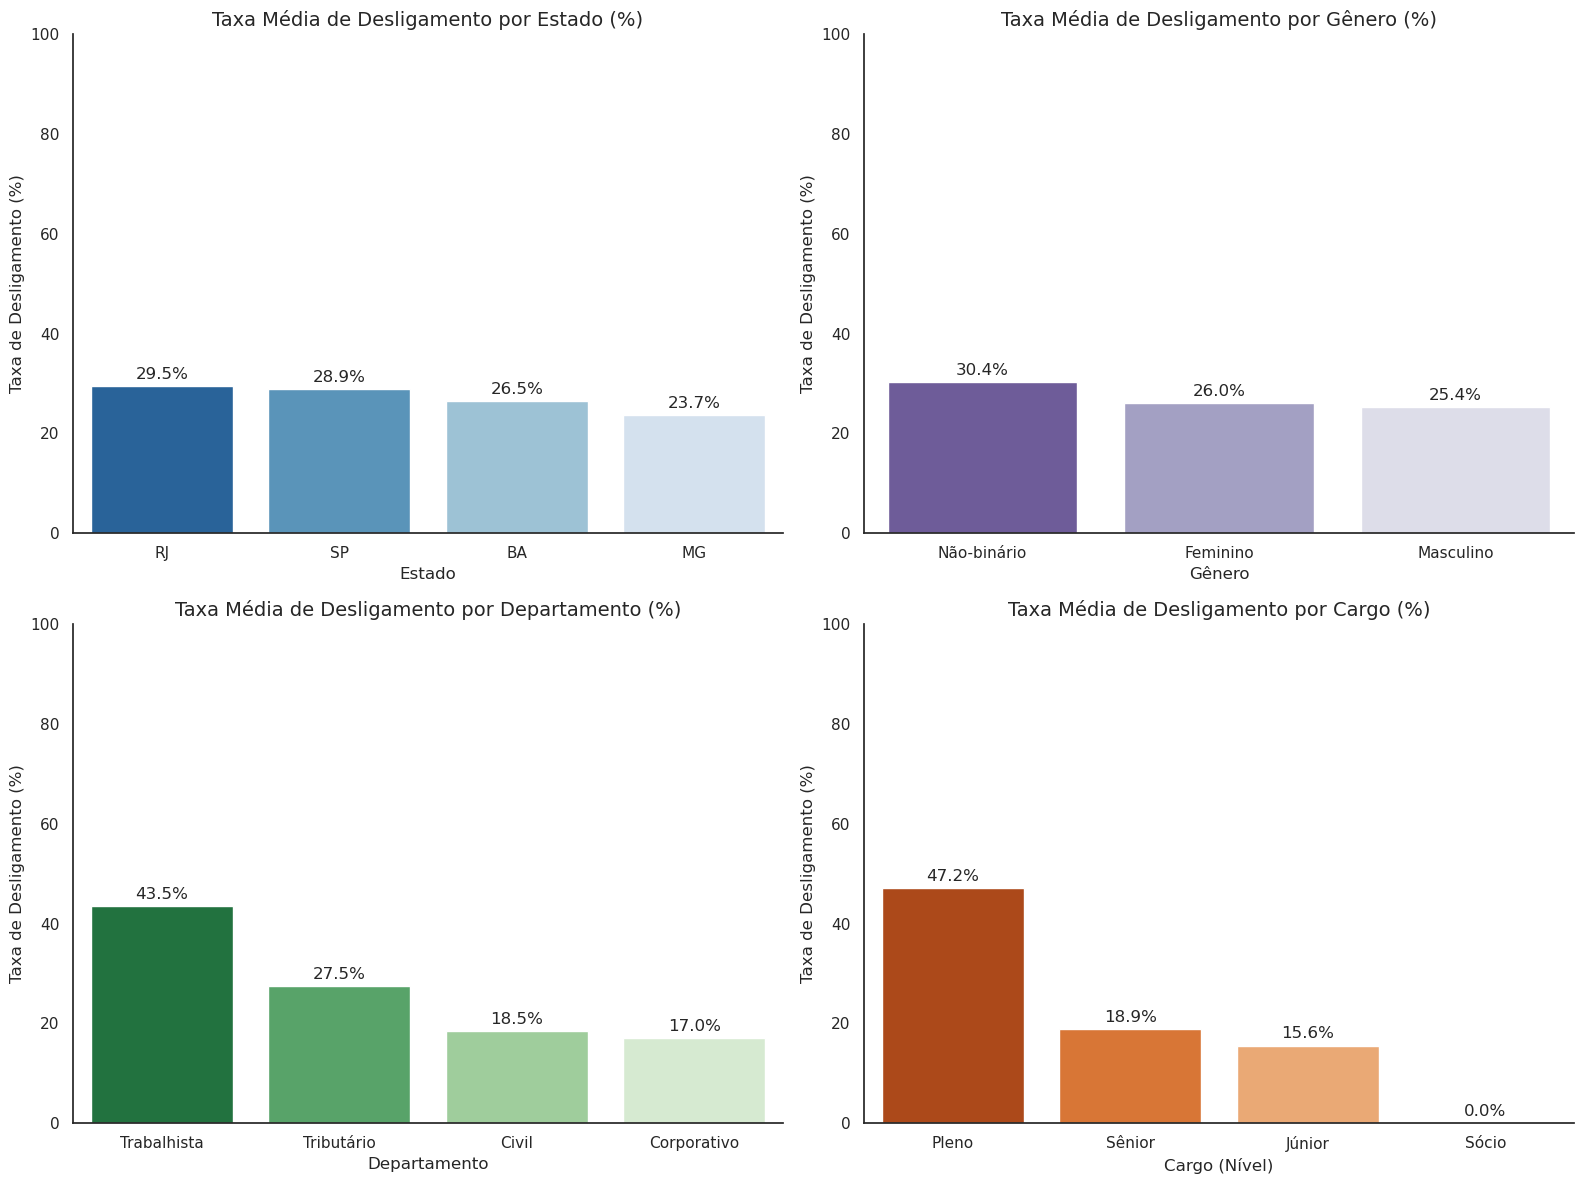

In [105]:
df_analise['desligado'] = (df_analise['status_atual'] == 'Desligado').astype(int)

estado_df = df_analise.groupby('estado', as_index=False)['desligado'].mean().assign(desligado=lambda x: x['desligado'] * 100).sort_values('desligado', ascending=False)
genero_df = df_analise.groupby('genero', as_index=False)['desligado'].mean().assign(desligado=lambda x: x['desligado'] * 100).sort_values('desligado', ascending=False)
depto_df = df_analise.groupby('nome_departamento', as_index=False)['desligado'].mean().assign(desligado=lambda x: x['desligado'] * 100).sort_values('desligado', ascending=False)
cargo_df = df_analise.groupby('nivel', as_index=False)['desligado'].mean().assign(desligado=lambda x: x['desligado'] * 100).sort_values('desligado', ascending=False)

sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=estado_df, x='estado', y='desligado', ax=axes[0,0], palette='Blues_r', hue='estado')
axes[0,0].set_title('Taxa Média de Desligamento por Estado (%)', fontsize=14)
axes[0,0].set_ylabel('Taxa de Desligamento (%)')
axes[0,0].set_xlabel('Estado')
axes[0,0].set_ylim(0, 100) 

sns.barplot(data=genero_df, x='genero', y='desligado', ax=axes[0,1], palette='Purples_r', hue='genero')
axes[0,1].set_title('Taxa Média de Desligamento por Gênero (%)', fontsize=14)
axes[0,1].set_ylabel('Taxa de Desligamento (%)')
axes[0,1].set_xlabel('Gênero')
axes[0,1].set_ylim(0, 100)

sns.barplot(data=depto_df, x='nome_departamento', y='desligado', ax=axes[1,0], palette='Greens_r', hue='nome_departamento')
axes[1,0].set_title('Taxa Média de Desligamento por Departamento (%)', fontsize=14)
axes[1,0].set_ylabel('Taxa de Desligamento (%)')
axes[1,0].set_xlabel('Departamento')
axes[1,0].set_ylim(0, 100) 

sns.barplot(data=cargo_df, x='nivel', y='desligado', ax=axes[1,1], palette='Oranges_r', hue='nivel')
axes[1,1].set_title('Taxa Média de Desligamento por Cargo (%)', fontsize=14)
axes[1,1].set_ylabel('Taxa de Desligamento (%)')
axes[1,1].set_xlabel('Cargo (Nível)')
axes[1,1].set_ylim(0, 100) 

for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

##### Análise estatística - Tabelas 

In [110]:
def criar_tabela(df, coluna_agrupamento):
    tabela_final = df.groupby(coluna_agrupamento)['score_satisfacao'].agg(
        Média='mean',
        Mediana='median'
    ).reset_index()
    
    tabela_final = tabela_final.sort_values('Média', ascending=False).round(2)
    
    return tabela_final

tabela_estado = criar_tabela(df_analise, 'estado')
tabela_estado.rename(columns={'estado': 'Estado'}, inplace=True)
display(tabela_estado.style\
    .format({"Média": "{:.2f}", "Mediana": "{:.2f}"})\
    .set_caption("Score de satisfação por estado"))

tabela_genero = criar_tabela(df_analise, 'genero')
tabela_genero.rename(columns={'genero': 'Gênero'}, inplace=True)
display(tabela_genero.style\
    .format({"Média": "{:.2f}", "Mediana": "{:.2f}"})\
    .set_caption("Score de satisfação por gênero"))

tabela_depto = criar_tabela(df_analise, 'nome_departamento')
tabela_depto.rename(columns={'nome_departamento': 'Departamento'}, inplace=True)
display(tabela_depto.style\
    .format({"Média": "{:.2f}", "Mediana": "{:.2f}"})\
    .set_caption("Score de satisfação por departamento"))

tabela_nivel = criar_tabela(df_analise, 'nivel')
tabela_nivel.rename(columns={'nivel': 'Nível'}, inplace=True)
display(tabela_nivel.style\
    .format({"Média": "{:.2f}", "Mediana": "{:.2f}"})\
    .set_caption("Score de satisfação por nível"))

tabela_status = criar_tabela(df_analise, 'status_atual')
tabela_status.rename(columns={'status_atual': 'Status'}, inplace=True)
display(tabela_status.style\
    .format({"Média": "{:.2f}", "Mediana": "{:.2f}"})\
    .set_caption("Score de satisfação por status"))

,Estado,Média,Mediana
3,SP,3.57,3.90
2,RJ,3.46,3.80
1,MG,3.42,3.70
0,BA,3.39,3.75


,Gênero,Média,Mediana
0,Feminino,3.50,3.90
1,Masculino,3.46,3.80
2,Não-binário,3.43,3.80


,Departamento,Média,Mediana
3,Tributário,4.18,4.20
0,Civil,4.10,4.10
1,Corporativo,4.07,4.10
2,Trabalhista,1.67,1.60


,Nível,Média,Mediana
3,Sócio,3.61,3.90
2,Sênior,3.54,3.85
1,Pleno,3.53,3.90
0,Júnior,3.36,3.70


,Status,Média,Mediana
0,Ativo,3.62,3.90
1,Desligado,3.04,3.45
